# Week 3: Image Processing, CNNs, and YOLO Fundamentals

**Objective:** This notebook bridges the gap from Artificial Neural Networks (ANNs) to the world of Computer Vision. We will explore how computers interpret images using **OpenCV**, understand the theory behind **Convolutional Neural Networks (CNNs)**, and apply a state-of-the-art object detection model, **YOLO**, to a live video stream.

**Core Concepts Covered:**
* **Image Processing:** Understanding images as matrices and manipulating them with OpenCV (reading, converting, drawing, filtering).
* **CNN Theory:** The concepts of Convolution, Kernels, Feature Maps, Pooling, and Flatten layers.
* **Object Detection:** The logic behind object detection (vs. classification).
* **YOLO (You Only Look Once):** Key concepts like Bounding Boxes, Confidence Scores, IoU, and NMS.
* **YOLOv8 Application:** Using a pre-trained YOLOv8 model for object detection on images and videos.

---

## Part 1: The "Why" - From ANNs to CNNs

In Week 2, we built a Neural Network (an ANN or MLP) to classify MNIST digits. To do this, we had to **flatten** the 28x28 pixel image into a 1D vector of 784 pixels.

**The Problem:** This process throws away all **spatial information**. The network has no idea that pixel `(0,0)` is next to pixel `(0,1)` or that pixel `(5,5)` is part of a line or curve. It treats every pixel as an independent feature.

**The Solution:** **Convolutional Neural Networks (CNNs)**. CNNs are specifically designed to process grid-like data (like images) by using filters (kernels) that slide over the image, preserving and learning from the spatial relationships between pixels to detect features like edges, corners, textures, and shapes.

---

## Part 2: What is Image Processing?

Before we build a CNN, let's understand what an image is. A digital image is just a large matrix (or 3D tensor) of numbers. Each number represents the brightness or color value of a single pixel.

* **Grayscale Image:** A 2D matrix (e.g., 800x600). Each value is 0 (black) to 255 (white).
* **Color Image:** A 3D matrix (e.g., 800x600x3). It has 3 channels (Red, Green, Blue) stacked together.

**Image Processing** is simply performing mathematical operations on this matrix to change it (e.g., make it brighter, blur it) or to get information from it (e.g., find edges).

Our main tool for this is **OpenCV (Open Source Computer Vision Library)**.

### 2.1 - Setup and Basic Operations

Let's import our libraries and load a sample image. We'll use `matplotlib.pyplot` to display images inside the notebook.

**Note:** OpenCV reads images in **BGR** (Blue, Green, Red) format by default, while `matplotlib` displays them in **RGB** (Red, Green, Blue). We must convert the color channels to see the correct colors.

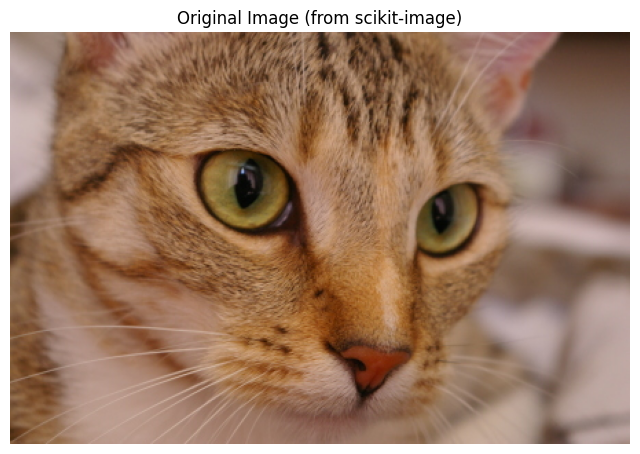

Image shape: (300, 451, 3)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data  # Import the data module

# 1. Load a sample image directly (no download needed)
# This loads the image as an RGB NumPy array.
img_rgb = data.chelsea()

# 2. No conversion is needed, as it's already in RGB.
# We will just make a BGR copy for later OpenCV operations if needed.
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

# 3. Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Original Image (from scikit-image)')
plt.axis('off')
plt.show()

print(f"Image shape: {img_rgb.shape}") # (Height, Width, Channels)

### 2.2 - Uygulama 1: Drawing on an Image

A key part of object detection is **annotating** an image—drawing bounding boxes and labels on it. OpenCV makes this easy.

We will draw:
1.  A **rectangle** around one of the dogs using `cv2.rectangle()`.
2.  **Text** above the box using `cv2.putText()`.

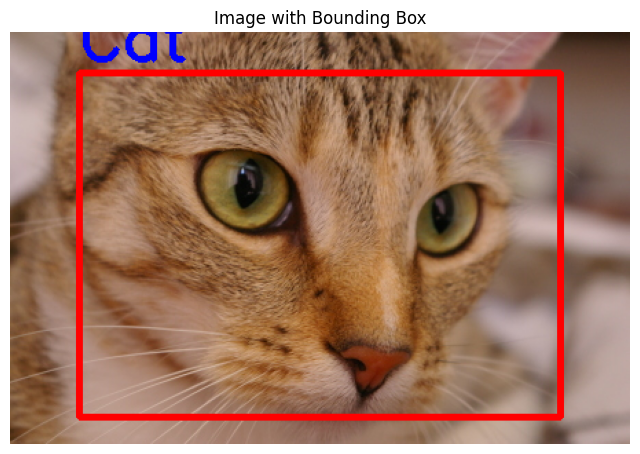

In [2]:
# We should always work on a copy to avoid changing the original image
annotated_image = img_rgb.copy()

# Define coordinates for the bounding box: (x_start, y_start) and (x_end, y_end)
# These coordinates are estimated for the full 'chelsea' cat face
pt1 = (50, 30)   # Top-left corner
pt2 = (400, 280)  # Bottom-right corner
color = (255, 0, 0) # Red color in RGB
thickness = 4

# 1. Draw the rectangle
cv2.rectangle(annotated_image, pt1, pt2, color, thickness)

# 2. Draw the text
text = "Cat"
text_pos = (50, 20) # Just above the top-left corner
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.5 # Adjusted scale for this image
text_color = (0, 0, 255) # Blue color
text_thickness = 3

cv2.putText(annotated_image, text, text_pos, font, font_scale, text_color, text_thickness)

# Display the annotated image
plt.figure(figsize=(8, 6))
plt.imshow(annotated_image)
plt.title('Image with Bounding Box')
plt.axis('off')
plt.show()

### 2.3 - Common Operations: Grayscale, Blurring, and Edge Detection

These are fundamental techniques in traditional computer vision. **Edge detection**, in particular, is what CNNs learn to do automatically with their first-layer kernels.

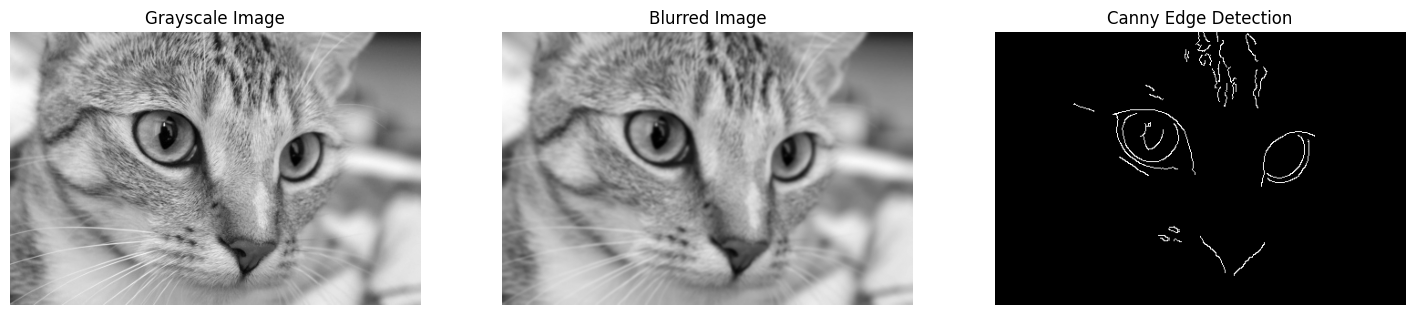

In [3]:
# 1. Convert to Grayscale
gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2. Apply Gaussian Blur (to reduce noise)
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# 3. Detect Edges using Canny Edge Detector
canny_edges = cv2.Canny(blurred_image, threshold1=100, threshold2=200)

# Plot all the results
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()

---

## Part 3: Understanding CNNs (Conceptual Overview)

Based on our presentation, a CNN has two main parts:
1.  **Feature Extraction:** A series of **Convolution** and **Pooling** layers that automatically learn features from the image.
2.  **Classification:** A standard **Dense** network (like in Week 2) that takes the learned features and makes a final decision.

### CNN Layer Flow:
**Input Image** → **[ [Convolution → Pooling] → [Convolution → Pooling] ... ]** → **Flatten** → **Dense** → **Output**

### Key Layers Explained:

1.  **Convolution (Conv) Layer:**
    * **Kernel (Filter):** A small matrix (e.g., 3x3) that slides over the input image.
    * **Function:** It performs a sliding dot-product. Each kernel is specialized to find one feature (e.g., a vertical edge, a specific color, a texture).
    * **Output (Feature Map):** The result of the convolution. It's an "image" that shows where the kernel's feature was activated (e.g., a map of all vertical edges).

2.  **Pooling Layer (e.g., Max Pooling):**
    * **Function:** Downsamples the feature map, making it smaller (e.g., taking the max value from every 2x2 block).
    * **Purpose:**
        * Reduces computation for the next layers.
        * Makes the model **robust** to small changes. (It doesn't matter *exactly* where the edge is, just that it's *in that general area*).

3.  **Flatten Layer:**
    * **Function:** Converts the final 2D feature maps into a 1D vector, so it can be fed into the Dense layers for classification.

4.  **Dense Layer:**
    * **Function:** The same as our Week 2 ANN. It makes the final prediction based on the features the convolution layers extracted.

### Keras Example (for MNIST - *Conceptual*)

Here is how the MNIST model from Week 2 *should* be built as a CNN. Notice we **do not flatten** the image at the start. We feed the 28x28x1 image directly to the `Conv2D` layer.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)


Starting CNN model training...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.9099 - loss: 0.3067 - val_accuracy: 0.9780 - val_loss: 0.0716
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9822 - loss: 0.0564 - val_accuracy: 0.9865 - val_loss: 0.0497
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9895 - loss: 0.0352 - val_accuracy: 0.9775 - val_loss: 0.0856
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9932 - loss: 0.0211 - val_accuracy: 0.9887 - val_loss: 0.0514
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9883 - val_loss: 0.0495
Training complete!

Evaluating on Test Data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9838 - loss: 0.0484

Test Accuracy: 98.73%
Test Loss: 0.0399


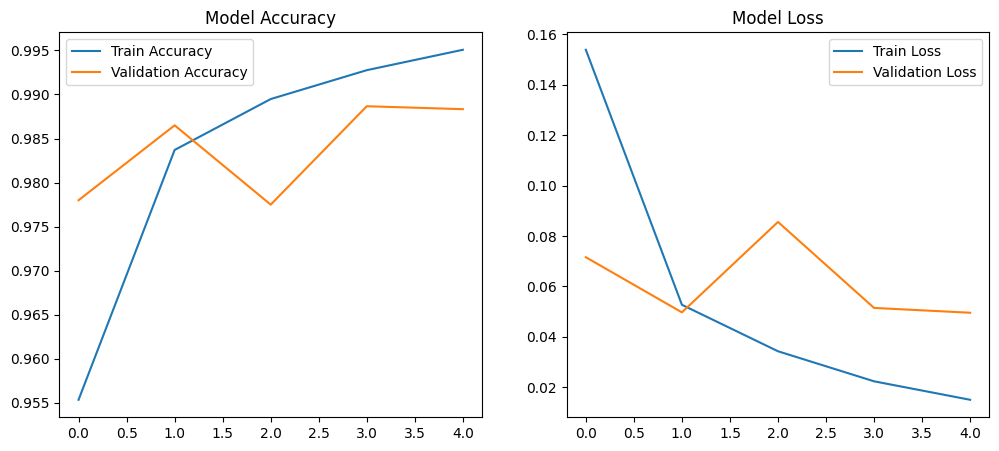

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load and Prepare MNIST Data ---

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape data for a CNN
# We need to add a "channel" dimension (1 for grayscale)
# Shape becomes (num_samples, 28, 28, 1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels (e.g., 5 -> [0,0,0,0,0,1,0,0,0,0])
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# --- 2. Build the CNN Model ---

cnn_model = Sequential([
    # Convolutional Layer: Learns 32 different 3x3 features
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),

    # Pooling Layer: Downsamples the feature maps
    MaxPooling2D(2,2),

    # Flatten Layer: Converts 2D maps to a 1D vector
    Flatten(),

    # Dense Layer (Classifier)
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

# --- 3. Compile the Model ---
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# --- 4. Train the Model ---
print("\nStarting CNN model training...")
history = cnn_model.fit(
    X_train,
    y_train_cat,
    epochs=5,  # 5 epochs is enough for a good result
    batch_size=32,
    validation_split=0.1
)
print("Training complete!")

# --- 5. Evaluate the Model ---
print("\nEvaluating on Test Data...")
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

# --- 6. Plot Training History ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

---

## Part 4: Uygulama 2 - Object Detection with YOLOv8

While CNNs are great for *classification* (is this a cat or a dog?), we often want to perform **object detection** (where *is* the cat in the image? And where is the dog?).

### What is YOLO (You Only Look Once)?

YOLO is an extremely fast, state-of-the-art object detection model. It works by:
1.  **Dividing** the image into a grid.
2.  **Predicting** (in a *single pass*) three things for each object:
    * **Bounding Box (BBox):** The (x, y, w, h) coordinates of the box around the object.
    * **Confidence Score:** How sure the model is that this box *contains an object* (any object).
    * **Class Probability:** The probability that the object in the box is a 'dog', 'cat', 'person', etc.

It then uses **Non-Max Suppression (NMS)** to clean up duplicate boxes for the same object, keeping only the one with the highest confidence.

### 4.1 - Setup YOLOv8

We will use the `ultralytics` library, which makes it incredibly simple to use YOLO.

In [4]:
# Install the ultralytics library
!pip install -q ultralytics


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from ultralytics import YOLO
import os

# Load a pre-trained YOLOv8 model
# 'yolov8n.pt' is the 'nano' version, which is very fast but less accurate.
# Other options: yolov8s.pt (small), yolov8m.pt (medium), etc.
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\berkd\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 4.2 - Run Inference on a Static Image

Let's run our model on the image of the cat we used earlier.


0: 448x640 1 cat, 246.6ms
Speed: 41.4ms preprocess, 246.6ms inference, 18.6ms postprocess per image at shape (1, 3, 448, 640)


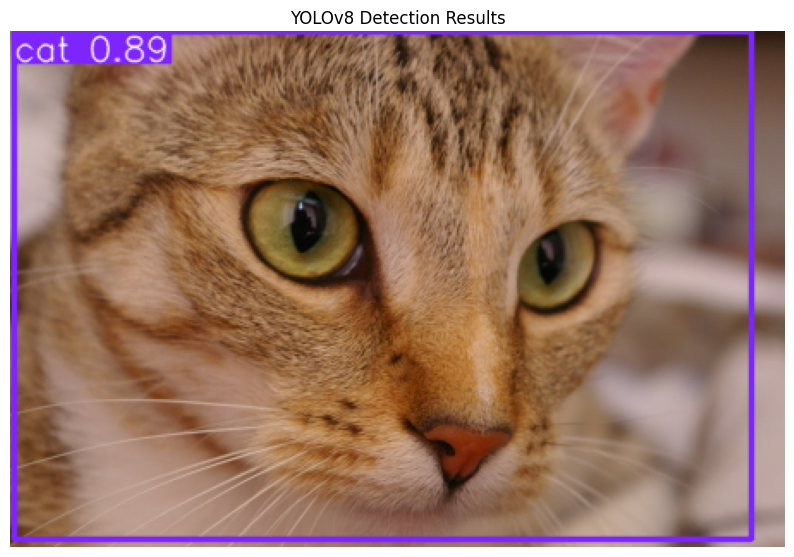

In [6]:
# Run the model on our sample image
results = model(img_bgr)

# The 'results' object contains all the detections.
# We can easily plot the results on the image.
annotated_frame = results[0].plot()

# Display the annotated image (need to convert BGR back to RGB for plt)
annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(annotated_frame_rgb)
plt.title('YOLOv8 Detection Results')
plt.axis('off')
plt.show()

### 4.3 - Uygulama 2: Object Detection on a Video Stream

The real power of YOLO is its speed, which makes it perfect for video. Let's download a sample video and run detection on it.

Running `model('video.mp4', save=True)` will process the video and save a new, annotated video file in a `runs/detect/predict/` folder.

In [7]:
print("Starting video processing...")
# Run YOLOv8 detection on the video file
# 'save=True' tells YOLO to save the output video to a new file
results = model('person-bicycle-car-detection.mp4', save=True)

print("Video processing complete.")
print(f"Annotated video saved to the directory: {results[0].save_dir}")

# You can find the saved video (e.g., 'example_video.avi')
# in the file explorer on the left, inside the 'runs/detect/predict' folder.
# Download it to see the results!

Starting video processing...

WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/647) c:\Users\berkd\Desktop\GDG_Week3\person-bicycle-car-detection.mp4: 384x640 (no detections), 124.8ms
video 1/1 (frame 2/647) c:\Users\berkd\Desktop\GDG_Week3\person-bicycle-car-detection.mp4: 384x640 (no detections), 68.4ms
video 1/1 (frame 3/647) c:\Users\berkd\Desktop\GDG_Week3\person-bicycle-car-detection.mp4: 384x640 (no detections), 68.3ms
video 1/1 (frame 4/647) c:\Users\berkd\Desktop\GDG_Week3\per

---

## Part 5: Week 3 Homework

**Task:** Develop a small demo that performs object detection on a video stream and report its performance.

**Instructions:**
1.  **Choose your source:**
    * You can use a video file (like the example above, or find your own).
    * Or, if you are running this notebook on your **local machine** (not Colab), you can use your webcam.
2.  **Develop the Demo:** Write the Python code to run YOLOv8 on your chosen video source.
3.  **Report Performance:**
    * Add code to your loop to calculate and display the **FPS (Frames Per Second)**.
    * In a markdown cell, briefly discuss the **accuracy**. Is it detecting objects well? Does it miss any? Does it detect things that aren't there (false positives)?

### Homework Hint: Calculating FPS

To calculate FPS, you need to time how long it takes to process one frame.

```python
import time

# ... inside your loop ...
while True:
    start_time = time.time() # Start timer
    
    ret, frame = cap.read()
    if not ret:
        break
    
    # Run detection
    results = model(frame)
    annotated_frame = results[0].plot()

    # Calculate FPS
    end_time = time.time()
    fps = 1 / (end_time - start_time)
    
    # Put FPS text on the frame
    cv2.putText(annotated_frame, f'FPS: {int(fps)}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('YOLOv8 Live', annotated_frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
```

### Homework Hint: Webcam Code (Local Machine ONLY)

This code will **not** work in Google Colab. You must run it on your local computer.

In [8]:
# --- HOMEWORK CELL ---
# This code will only work on your local machine, not in Colab.

import cv2
from ultralytics import YOLO
import time

# Load the model
model = YOLO('yolov8n.pt')

# Initialize webcam (0 is usually the default webcam)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    # Start timer
    start_time = time.time()

    # Read a frame from the webcam
    ret, frame = cap.read()
    if not ret:
        print("Error: Failed to capture frame.")
        break

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Calculate FPS
    end_time = time.time()
    fps = 1 / (end_time - start_time)

    # Display the FPS on the frame
    cv2.putText(annotated_frame, f'FPS: {int(fps)}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show the annotated frame in a window
    cv2.imshow('YOLOv8 Live Detection', annotated_frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close windows
cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 166.2ms
Speed: 4.2ms preprocess, 166.2ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 149.8ms
Speed: 6.7ms preprocess, 149.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 110.3ms
Speed: 4.4ms preprocess, 110.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 106.4ms
Speed: 3.7ms preprocess, 106.4ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 104.4ms
Speed: 4.4ms preprocess, 104.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 102.0ms
Speed: 3.5ms preprocess, 102.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 139.3ms
Speed: 2.9ms preprocess, 139.3ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 92.6ms
Speed: 2.1ms preprocess, 92.6ms inference, 1.3ms postprocess per image at s

KeyboardInterrupt: 

### Homework Report

*(Write your report here)*

**1. Setup:**
* *(e.g., I used my built-in laptop webcam / I used an MP4 file of a highway.)*
* *(e.g., I used the 'yolov8n.pt' model.)*

**2. FPS Report:**
* *(e.g., On my machine, the 'yolov8n.pt' model ran at approximately 25-30 FPS.)*

**3. Accuracy/Performance Report:**
* *(e.g., The model was very accurate at detecting 'people' and 'cars'. It sometimes misclassified my 'cell phone' as a 'remote'. It also had trouble detecting my 'dog' unless its whole body was in the frame.)*